In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

## <font color='cornflowerblue'> Data

```tickers = ['BABA','MSFT','NVDA','PG','V','WM','GLD','GOOGL','AAPL','AMZN','ANET','ASML','AVGO','CRM','DIS','LLY','MKC','RL','JPM']```

## <font color='cornflowerblue'> Analysis

In [2]:
def get_fundamentals_data(ticker: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    base = f'FactSet/{ticker}/'
    if not os.path.exists(base):
        raise FileNotFoundError(f"Directory {base} does not exist.")
    
    # get balance sheet data
    bs = pd.read_excel(f'FactSet/{ticker}/bs.xlsx', skiprows=7)
    bs.set_index('Unnamed: 0', inplace=True)

    # get income statement data
    ist = pd.read_excel(f'FactSet/{ticker}/ist.xlsx', skiprows=7)
    ist.set_index('Unnamed: 0', inplace=True)

    # get cash flow data
    cf = pd.read_excel(f'FactSet/{ticker}/cf.xlsx', skiprows=7)
    cf.set_index('Unnamed: 0', inplace=True)

    # get ratio analysis data
    ra = pd.read_excel(f'FactSet/{ticker}/ra.xlsx', skiprows=7)
    ra.set_index('Unnamed: 0', inplace=True)

    return bs, ist, cf, ra

def plot_price(ticker: str) -> None:

    data = yf.download(ticker, period='5y', progress=False, auto_adjust=True)['Close']

    plt.figure(figsize=(14, 4))
    plt.plot(data.index, data.values, label=f'{ticker} Stock Price', color='navy')
    plt.title(f'{ticker} Stock Price over the Last 5 Years')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_profitability(profitability_metrics: list[str], ra: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

    axes = axes.flatten()
    x = ra.columns

    for ax, metric in zip(axes, profitability_metrics):
        ax.plot(x, ra.loc[metric], marker='o', color='navy')
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(x, rotation=45)
        ax.grid(True, which='major', alpha=0.4)

    plt.tight_layout()
    plt.show()

def plot_valuation(valuation_metrics: list[str], ra: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

    axes = axes.flatten()
    x = ra.columns

    for ax, metric in zip(axes, valuation_metrics):
        ax.plot(x, ra.loc[metric], marker='o', color='navy')
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(x, rotation=45)
        ax.grid(True, which='major', alpha=0.4)

    plt.tight_layout()
    plt.show()

def plot_liquidity_coverage_leverage(liquidity_metrics: list[str], ra: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)

    axes = axes.flatten()
    x = ra.columns

    for ax, metric in zip(axes, liquidity_metrics):
        ax.plot(x, ra.loc[metric], marker='o', color='navy')
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(x, rotation=45)
        ax.grid(True, which='major', alpha=0.4)

    plt.tight_layout()
    plt.show()

def plot_debt(debt_metrics: list[str], bs: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    axes = axes.flatten()
    x = bs.columns

    for ax, metric in zip(axes, debt_metrics):
        ax.plot(x, bs.loc[metric], marker='o', color='navy')
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(x, rotation=45)
        ax.grid(True, which='major', alpha=0.4)

    plt.tight_layout()
    plt.show()

def plot_margins(ra: pd.DataFrame) -> None:
    plt.figure(figsize=(14, 4))

    plt.plot(ra.loc['Gross Margin'], color='navy', marker='o', label='Gross Margin')
    plt.plot(ra.loc['Operating Margin'], color='royalblue', marker='o', label='Operating Margin')
    plt.plot(ra.loc['Net Margin'], color='skyblue', marker='o', label='Net Margin')
    plt.xticks(rotation=45)
    
    plt.title('Profitability')
    plt.xlabel('Date')
    plt.ylabel('Percentage')
    plt.legend()
    plt.grid()
    plt.show()

def plot_sales(ist: pd.DataFrame) -> None:
    plt.figure(figsize=(14, 4))

    plt.plot(ist.loc['Sales'], color='navy', marker='o', label='Sales')
    plt.plot(ist.loc['COGS excluding D&A'], color='royalblue', marker='o', label='COGS excluding D&A')
    plt.xticks(rotation=45)
    
    plt.title('Sales')
    plt.xlabel('Date')
    plt.ylabel('Sales Amount')
    plt.legend()
    plt.grid()
    plt.show()

def barplot_debt(bs: pd.DataFrame) -> None:
    total_debt = bs.loc['ST Debt & Curr. Portion LT Debt'] + bs.loc['Long-Term Debt']

    df = pd.DataFrame({
        'ST Debt': bs.loc['ST Debt & Curr. Portion LT Debt'],
        'LT Debt': bs.loc['Long-Term Debt']
    }, index=bs.loc['Long-Term Debt'].index)

    plt.figure(figsize=(14, 6))
    plt.bar(df.index, df['ST Debt'], width=0.3, label='ST Debt', color='steelblue')
    plt.bar(df.index, df['LT Debt'], width=0.3, bottom=df['ST Debt'], label='LT Debt', color='skyblue')
    plt.plot(df.index, total_debt.values, marker='o', c = 'navy')
    plt.xticks(rotation=45)

    plt.title('Total Debt')
    plt.xlabel('Date')
    plt.ylabel('Debt')
    plt.legend()
    plt.show()

def plot_ebitda(ist: pd.DataFrame) -> None:
    plt.figure(figsize=(14, 4))

    plt.plot(ist.loc['EBITDA'].iloc[1], color='navy', marker='o', label='EBITDA')
    plt.plot(ist.loc['EBIT (Operating Income)'], color='royalblue', marker='o', label='EBIT')
    plt.plot(ist.loc['Interest Expense'], color='skyblue', marker='o', label='Interest Expense')
    plt.xticks(rotation=45)
    
    plt.title('EBITDA')
    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.legend()
    plt.grid()
    plt.show()

def plot_fcf(cf: pd.DataFrame) -> None:
    plt.figure(figsize=(14, 4))

    plt.plot(cf.loc['Free Cash Flow'], color='navy', marker='o', label='Free Cash Flow')
    plt.xticks(rotation=45)
    
    plt.title('Free Cash Flow')
    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.legend()
    plt.grid()
    plt.show()

In [3]:
def ts_percentile(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 4:
        return np.nan
    return series.rank(pct=True).iloc[-1]

def trend_score(series: pd.Series, weights=(0.5, 0.3, 0.2)) -> float:
    """
    Measures cumulative growth over 1Y, 2Y, 3Y periods
    """
    s = series.dropna()
    if len(s) < 13:
        return np.nan
    
    try:
        # Cumulative returns over periods
        t1 = (s.iloc[-1] - s.iloc[-5]) / s.iloc[-5]   # Last 1 year (4 quarters)
        t2 = (s.iloc[-1] - s.iloc[-9]) / s.iloc[-9]   # Last 2 years (8 quarters)
        t3 = (s.iloc[-1] - s.iloc[-13]) / s.iloc[-13] # Last 3 years (12 quarters)
    except (IndexError, ZeroDivisionError):
        return np.nan
    
    # Normalize to [-1, 1] range (could use tanh or custom scaling)
    trend = (
        weights[0] * t1 +
        weights[1] * t2 +
        weights[2] * t3
    )
    
    return np.clip(trend, -1, 1)

def metric_score(series: pd.Series, negative=False) -> float:
    level = ts_percentile(series)
    trend = trend_score(series)

    if np.isnan(level):
        return np.nan

    if negative:
        level = 1 - level

    if np.isnan(trend):
        return level

    return np.clip(level * (1 + 0.25 * trend), 0, 1)

PROFITABILITY = {
    'Gross Margin': 0.15,
    'Operating Margin': 0.20,
    'Net Margin': 0.15,
    'Return on Equity ': 0.20,
    'Return on Invested Capital': 0.30
}

GROWTH = {
    'Sales': 0.30,
    'EBITDA': 0.25,
    'EBIT (Operating Income)': 0.20,
    'EPS (basic)': 0.25
}

CASH_FLOW = {
    'Free Cash Flow': 0.60,
    'Free Cash Flow Margin': 0.40
}

FINANCIAL_STRENGTH = {
    'Current Ratio (x)': (0.25, False),
    'Net Debt/EBITDA': (0.30, True),
    'Total Debt/EBITDA': (0.20, True),
    'EBIT/Interest Expense (Int. Coverage)': (0.25, False)
}

VALUATION = {
    'Price/Earnings': (0.50, True),
    'Price/Book Value': (0.25, True),
    'EPS (basic)': (0.25, False)
}

def score_profitability(ra: pd.DataFrame) -> float:
    score = 0.0
    for metric, w in PROFITABILITY.items():
        s = metric_score(ra.loc[metric])
        if np.isnan(s):
            s = 0.5
        score += w * s
    return score

def score_growth(ist: pd.DataFrame) -> float:
    score = 0.0
    for metric, w in GROWTH.items():
        s = metric_score(ist.loc[metric])
        if np.isnan(s):
            s = 0.5
        score += w * s
    return score

def score_cash_flow(cf: pd.DataFrame, ra: pd.DataFrame) -> float:
    s1 = metric_score(cf.loc['Free Cash Flow'])
    s2 = metric_score(ra.loc['Free Cash Flow Margin'])

    s1 = 0.5 if np.isnan(s1) else s1
    s2 = 0.5 if np.isnan(s2) else s2

    return 0.6 * s1 + 0.4 * s2

def score_financial_strength(ra: pd.DataFrame) -> float:
    score = 0.0
    for metric, (w, neg) in FINANCIAL_STRENGTH.items():
        s = metric_score(ra.loc[metric], negative=neg)
        if np.isnan(s):
            s = 0.5
        score += w * s
    return score

def score_valuation(ra: pd.DataFrame) -> float:
    score = 0.0
    for metric, (w, neg) in VALUATION.items():
        s = metric_score(ra.loc[metric], negative=neg)
        if np.isnan(s):
            s = 0.5
        score += w * s
    return score

def stock_score(bs, ist, cf, ra) -> dict:
    scores = {
        'Profitability': score_profitability(ra),
        'Growth': score_growth(ist),
        'Cash Flow': score_cash_flow(cf, ra),
        'Financial Strength': score_financial_strength(ra),
        'Valuation': score_valuation(ra)
    }

    final = (
        0.35 * scores['Profitability'] +
        0.25 * scores['Growth'] +
        0.15 * scores['Cash Flow'] +
        0.15 * scores['Financial Strength'] +
        0.10 * scores['Valuation']
    )

    scores['Final Score'] = round(100 * final, 2)
    return scores

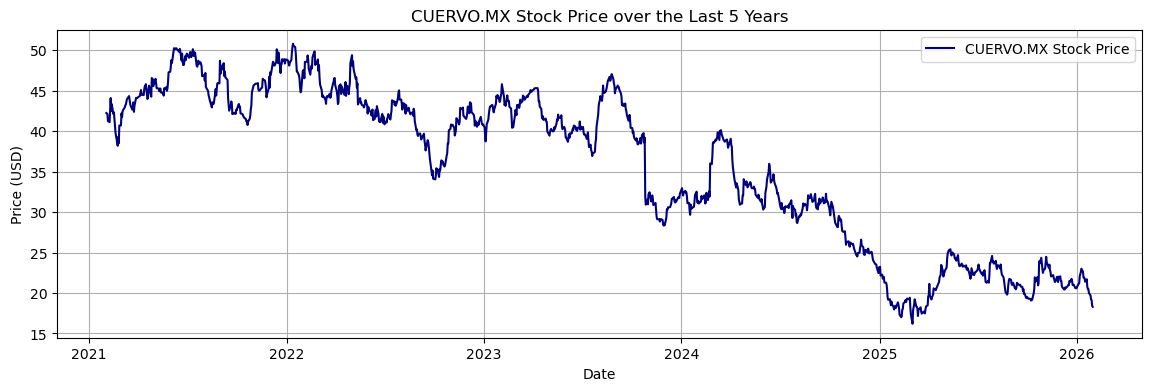

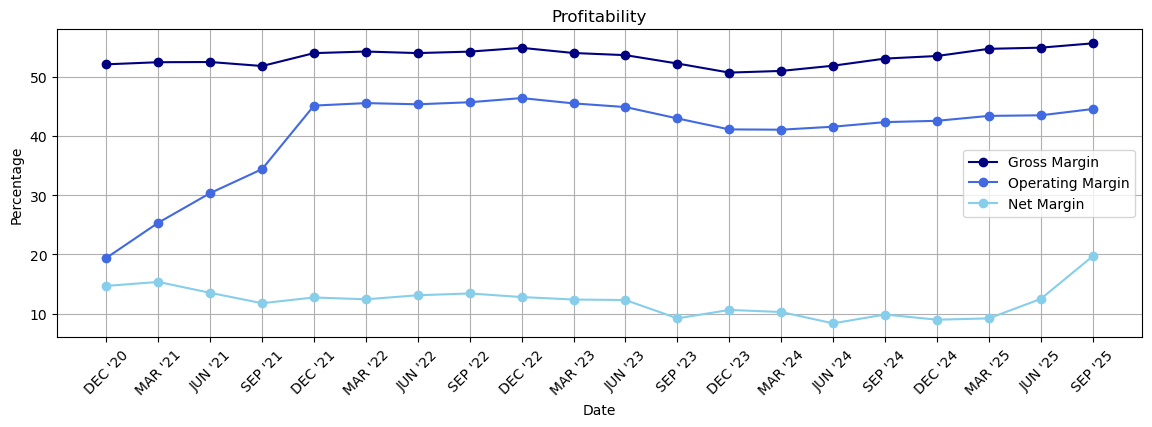

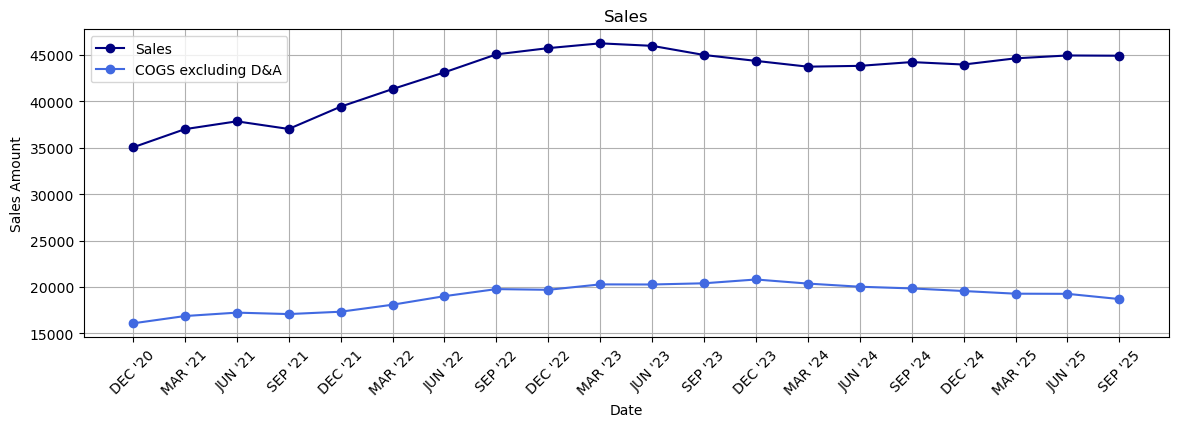

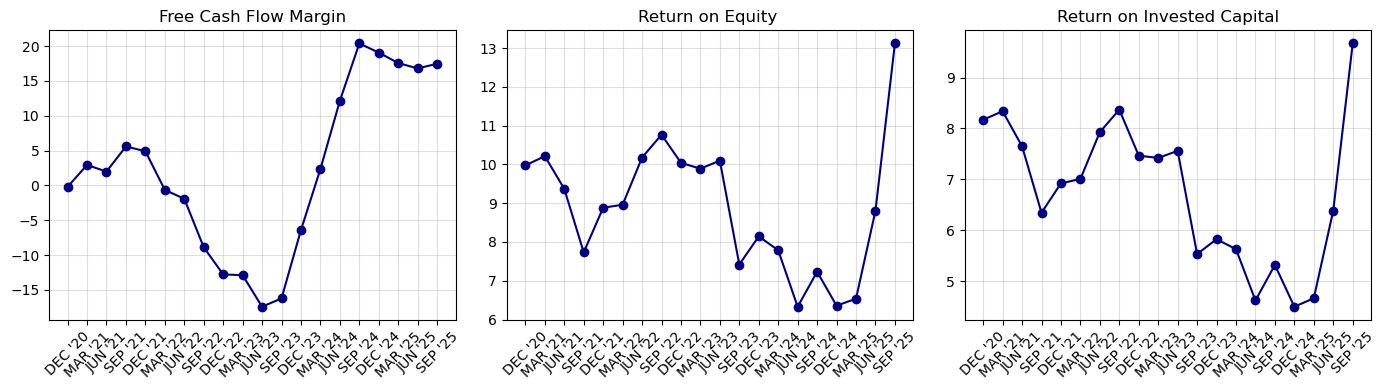

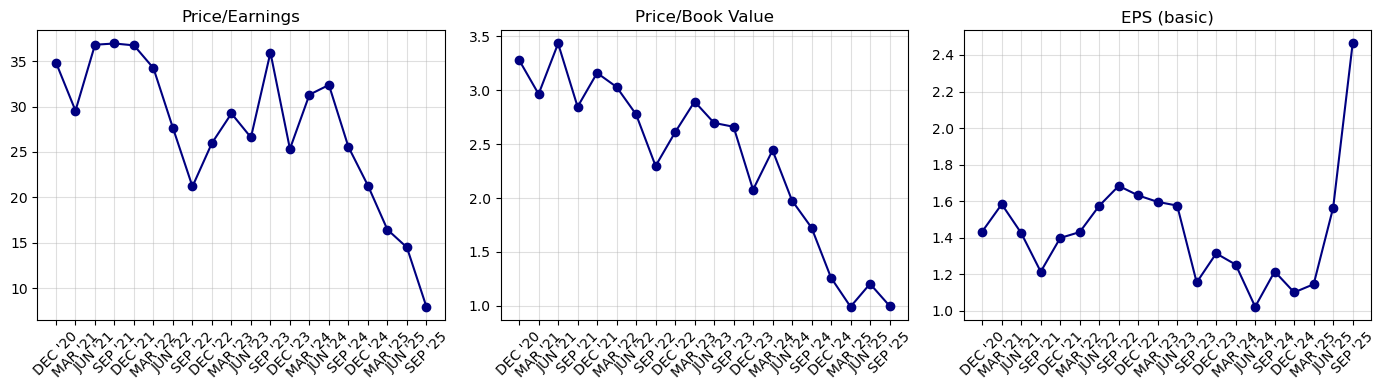

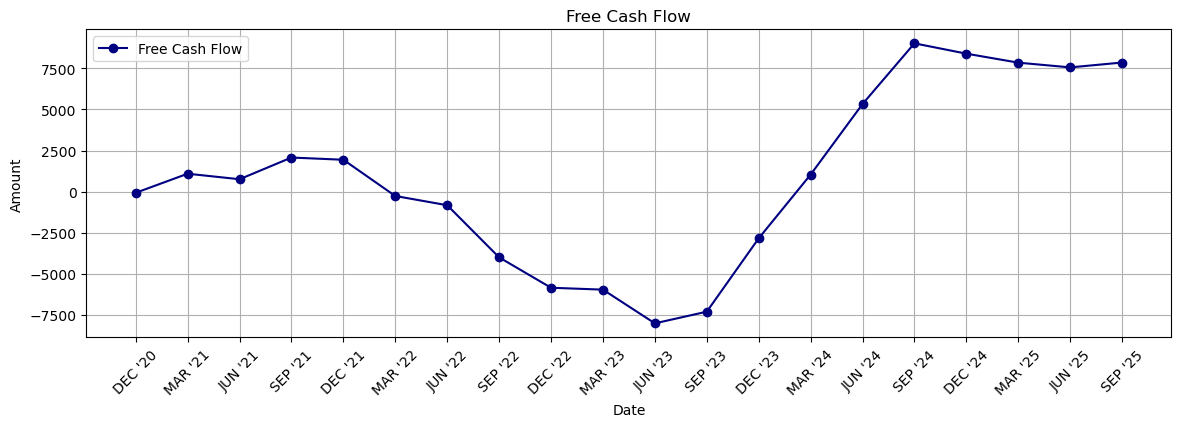

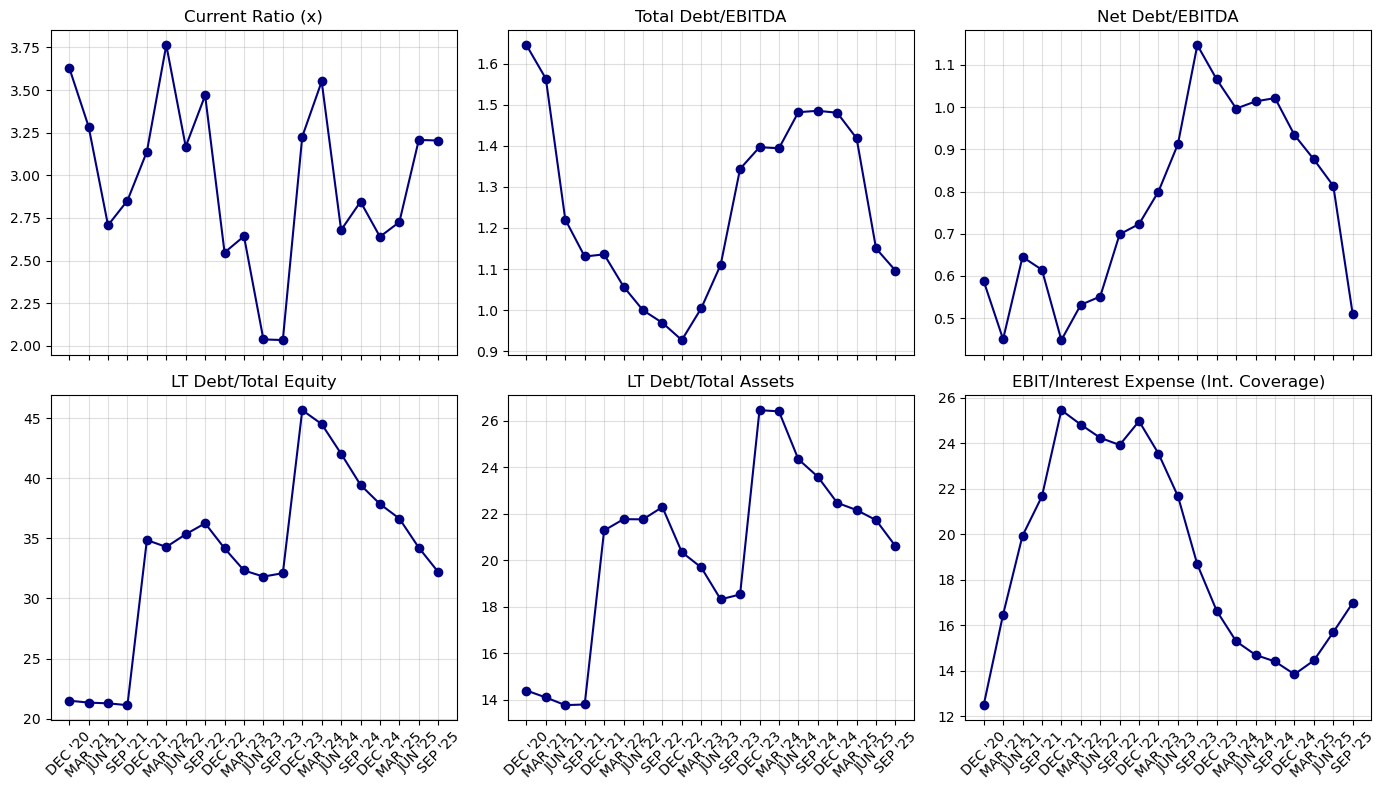

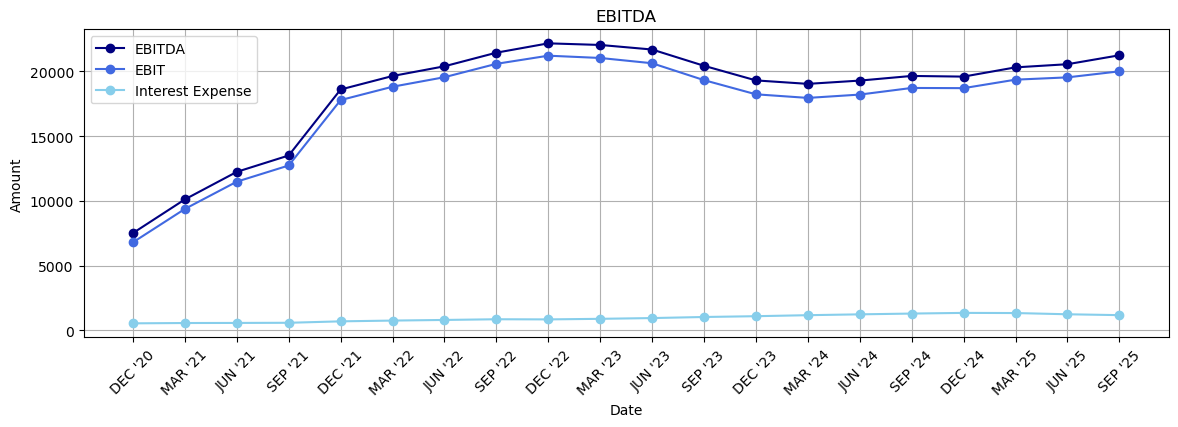

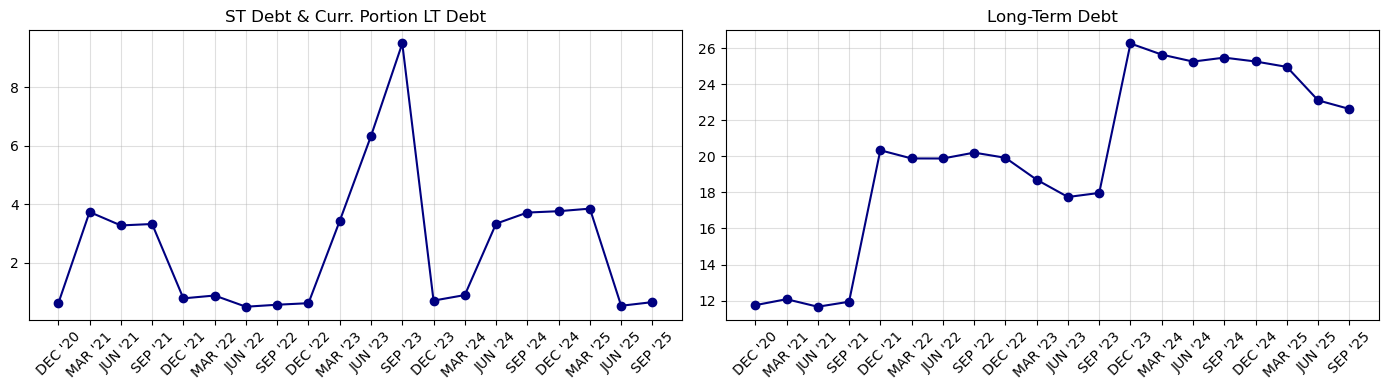

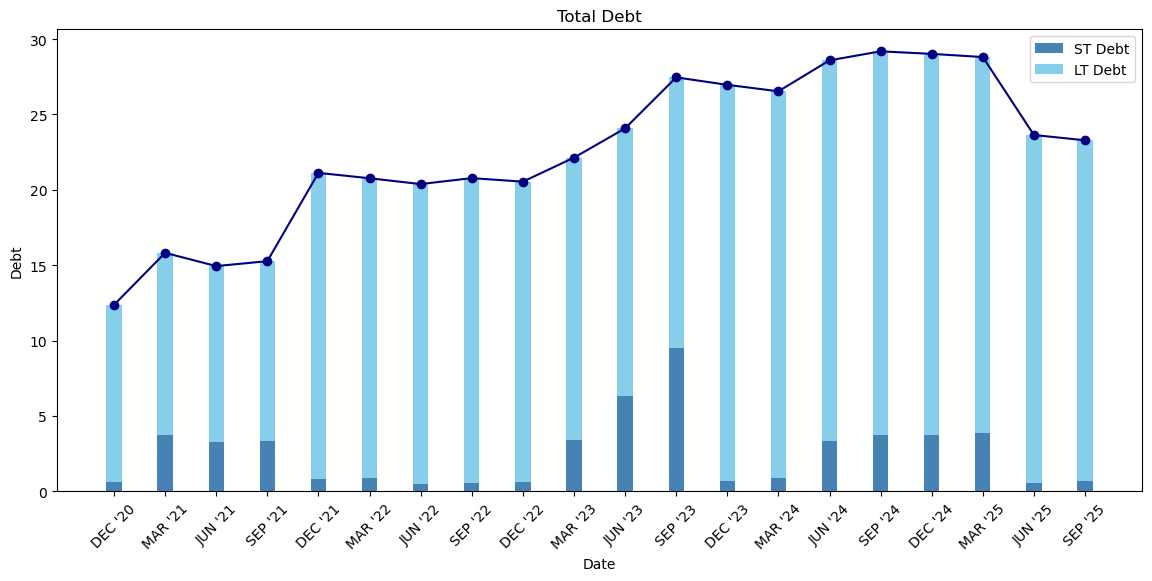

In [4]:
ticker = 'CUERVO.MX'

bs, ist, cf, ra = get_fundamentals_data(ticker)

profitability_metrics = [
    'Free Cash Flow Margin',
    'Return on Equity ',
    'Return on Invested Capital',
]

valuation_metrics = [
    'Price/Earnings',
    'Price/Book Value',
    'EPS (basic)'
]

liquidity_metrics = [
    'Current Ratio (x)',
    'Total Debt/EBITDA',
    'Net Debt/EBITDA',
    'LT Debt/Total Equity',
    'LT Debt/Total Assets',
    'EBIT/Interest Expense (Int. Coverage)'
]

debt_metrics = [
    'ST Debt & Curr. Portion LT Debt',
    'Long-Term Debt'
]

try: 
    plot_price(ticker)
    plot_margins(ra)
    plot_sales(ist)
    plot_profitability(profitability_metrics, ra)
    plot_valuation(valuation_metrics, ra)
    plot_fcf(cf)
    plot_liquidity_coverage_leverage(liquidity_metrics, ra)
    plot_ebitda(ist)
    plot_debt(debt_metrics, bs)
    barplot_debt(bs)
except Exception as e:
    print(f"An error occurred while plotting: {e}")

## <font color='cornflowerblue'> Analysts projections and recommendations

In [5]:
info = yf.Ticker(ticker)
price_targets = info.analyst_price_targets
recommendations = info.recommendations

start_date = (datetime.today() - timedelta(days=3)).strftime('%Y-%m-%d')
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

price = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']
current_price = price.iloc[-1].values

print(f'Expected 1y growth \n')
for stat, price in price_targets.items():
    pct = price / current_price - 1
    print(f'{stat}: {pct[0]:.2%}')

recommendations

Expected 1y growth 

current: 0.71%
high: 85.89%
low: 20.28%
mean: 52.00%
median: 53.09%


,period,strongBuy,buy,hold,sell,strongSell
0,0m,2,5,4,0,0
1,-1m,2,5,4,0,0
2,-2m,1,4,6,0,0


## <font color='cornflowerblue'> Stocks Scorings

In [6]:
scores = stock_score(bs, ist, cf, ra)

for k, v in scores.items():
    print(f'{k}: {v:.2f}')

print(f"\nLast ROIC: {ra.loc['Return on Invested Capital'][-1]:.2f}%")
print(f"Sales Growth (1Y): {round((ist.loc['Sales'][-1] / ist.loc['Sales'][-5] - 1) * 100, 4)}%")

Profitability: 0.93
Growth: 0.75
Cash Flow: 0.66
Financial Strength: 0.66
Valuation: 0.84
Final Score: 79.38

Last ROIC: 9.67%
Sales Growth (1Y): 1.5475%


In [7]:
tickers = ['BABA','MSFT','NVDA','PG','V','WM','GLD','GOOGL','AAPL','AMZN','ANET','ASML','AVGO','CRM','DIS','LLY','MKC','RL','JPM']
stored_scores = {}

for ticker in tickers:

    try:
        bs, ist, cf, ra = get_fundamentals_data(ticker)

        scores = stock_score(bs, ist, cf, ra)

    except Exception as e:
        print(f'‼️‼️ Error retrieving data for {ticker}: {e} ‼️‼️')
        print('-' * 50 + '\n')
        continue

    for k, v in scores.items():
        stored_scores.setdefault(k, []).append((ticker, v))

stored_scores['Final Score'].sort(key=lambda x: x[1], reverse=True)

for item in stored_scores['Final Score']:
    print(f'{item[0]}: {item[1]:.2f}')

‼️‼️ Error retrieving data for GLD: Directory FactSet/GLD/ does not exist. ‼️‼️
--------------------------------------------------

‼️‼️ Error retrieving data for ANET: 'Total Debt/EBITDA' ‼️‼️
--------------------------------------------------

‼️‼️ Error retrieving data for JPM: 'Gross Margin' ‼️‼️
--------------------------------------------------

LLY: 91.35
DIS: 90.74
CRM: 86.71
NVDA: 83.94
AMZN: 79.82
PG: 78.38
RL: 77.83
AVGO: 76.47
ASML: 75.00
GOOGL: 73.99
AAPL: 72.68
V: 69.26
MKC: 64.65
MSFT: 57.84
WM: 53.70
BABA: 52.87
